# LSTM Multi-Step Forecasting - MIT-BIH Arrhythmia Database


In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'

import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import wfdb
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tqdm.auto import tqdm
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input
from tensorflow.keras.callbacks import EarlyStopping

warnings.filterwarnings('ignore')
tf.random.set_seed(42)
np.random.seed(42)

print(f'TensorFlow: {tf.__version__}')
gpus = tf.config.list_physical_devices('GPU')
print(f'GPU available: {len(gpus) > 0}')
print('All imports OK.')

C:\Users\Abdallah\AppData\Roaming\Python\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



TensorFlow: 2.15.0
GPU available: False
All imports OK.


## 1. Configuration (Section 3, Dudukcu et al. 2023)

In [2]:
# Path to MIT-BIH Arrhythmia Database
DATA_DIR = "E:/NU internship/ecg_dataset/mitdb"

# Constants from the paper (Section 3)
FS           = 360        # sampling frequency (Hz)
TOTAL_STEPS  = 100_000    # samples per patient
TRAIN_STEPS  = 40_000     # training partition
VAL_STEPS    = 10_000     # validation partition
TEST_STEPS   = 50_000     # test partition

LOOKBACK     = 10         # input window (10 steps)
HORIZONS     = [10, 20, 50]  # multi-step prediction horizons

# 21 patients (excluding 111, 118 per paper)
PATIENTS = [
    '100', '101', '102', '103', '104', '105',
    '106', '107', '108', '109', '112', '113',
    '114', '115', '116', '117', '119',
    '121', '122', '123', '124'
]
assert len(PATIENTS) == 21

print(f'Patients       : {len(PATIENTS)}')
print(f'Sampling freq  : {FS} Hz')
print(f'Total steps/pt : {TOTAL_STEPS:,}')
print(f'Train/Val/Test : {TRAIN_STEPS:,} / {VAL_STEPS:,} / {TEST_STEPS:,}')
print(f'Lookback       : {LOOKBACK} steps ({LOOKBACK/FS*1000:.1f} ms)')
print(f'Horizons       : {HORIZONS}')

Patients       : 21
Sampling freq  : 360 Hz
Total steps/pt : 100,000
Train/Val/Test : 40,000 / 10,000 / 50,000
Lookback       : 10 steps (27.8 ms)
Horizons       : [10, 20, 50]


## 2. Preprocessing Functions

Pipeline follows Section 3 of the paper:
1. Load MLII lead from MIT-BIH using `wfdb`
2. Truncate/pad to 100,000 samples
3. Split: train (0-40k), val (40k-50k), test (50k-100k)
4. MinMax normalise (scaler fitted on train only)
5. Build sliding-window sequences: X = 10 steps, y = next H steps

In [3]:
def load_ecg_signal(record_id, data_dir, n_steps=100_000):
    '''Load MLII lead and return exactly n_steps samples.'''
    path = os.path.join(data_dir, record_id)
    rec = wfdb.rdrecord(path)
    sig_names = [s.upper() for s in rec.sig_name]
    ch = sig_names.index('MLII') if 'MLII' in sig_names else 0
    signal = rec.p_signal[:, ch].astype(np.float32)
    if len(signal) < n_steps:
        pad = np.full(n_steps - len(signal), signal[-1], dtype=np.float32)
        signal = np.concatenate([signal, pad])
    return signal[:n_steps]


def preprocess_patient(signal, train_steps=40_000, val_steps=10_000):
    '''Split and MinMax-normalise. Scaler fitted on train only.'''
    train_raw = signal[:train_steps]
    val_raw   = signal[train_steps:train_steps + val_steps]
    test_raw  = signal[train_steps + val_steps:]

    scaler     = MinMaxScaler(feature_range=(0, 1))
    train_norm = scaler.fit_transform(train_raw.reshape(-1, 1)).flatten()
    val_norm   = scaler.transform(val_raw.reshape(-1, 1)).flatten()
    test_norm  = scaler.transform(test_raw.reshape(-1, 1)).flatten()
    return train_norm, val_norm, test_norm, scaler


def make_sequences(signal, lookback=10, horizon=1):
    '''Sliding-window: X = (lookback,) -> y = (horizon,).'''
    X, y = [], []
    for i in range(len(signal) - lookback - horizon + 1):
        X.append(signal[i : i + lookback])
        y.append(signal[i + lookback : i + lookback + horizon])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)


print('Preprocessing functions defined.')

Preprocessing functions defined.


## 3. Load & Preprocess All Patients

In [4]:
patient_signals = {}

print(f'Loading {len(PATIENTS)} patients ...\n')
for rid in tqdm(PATIENTS, desc='Patients'):
    signal = load_ecg_signal(rid, DATA_DIR, n_steps=TOTAL_STEPS)
    tr, vl, te, sc = preprocess_patient(signal, TRAIN_STEPS, VAL_STEPS)
    patient_signals[rid] = {'train': tr, 'val': vl, 'test': te, 'scaler': sc}

print(f'\nDone - {len(patient_signals)} patients loaded.')

Loading 21 patients ...



Patients: 100%|██████████| 21/21 [00:00<00:00, 22.74it/s]


Done - 21 patients loaded.


## 4. Preprocessing Verification

In [5]:
all_ok = True
rows = []
for rid in PATIENTS:
    d = patient_signals[rid]
    len_ok   = (len(d['train']) == TRAIN_STEPS and
                len(d['val'])   == VAL_STEPS and
                len(d['test'])  == TEST_STEPS)
    scale_ok = d['train'].min() >= -1e-6 and d['train'].max() <= 1 + 1e-6
    nan_ok   = not (np.isnan(d['train']).any() or np.isnan(d['test']).any())
    ok = len_ok and scale_ok and nan_ok
    if not ok:
        all_ok = False
    rows.append({'Patient': rid, 'Length OK': len_ok, 'Scale OK': scale_ok, 'NaN free': nan_ok})

df_check = pd.DataFrame(rows).set_index('Patient')
display(df_check)
print('\nAll 21 patients pass checks.' if all_ok else '\nSome patients FAILED.')

,Length OK,Scale OK,NaN free
Patient,,,
100,True,True,True
101,True,True,True
102,True,True,True
103,True,True,True
104,True,True,True
105,True,True,True
106,True,True,True
107,True,True,True
108,True,True,True



All 21 patients pass checks.


## 5. Signal Visualisation (Sanity Check)

Plot normalised ECG for Patient 103 across partitions.

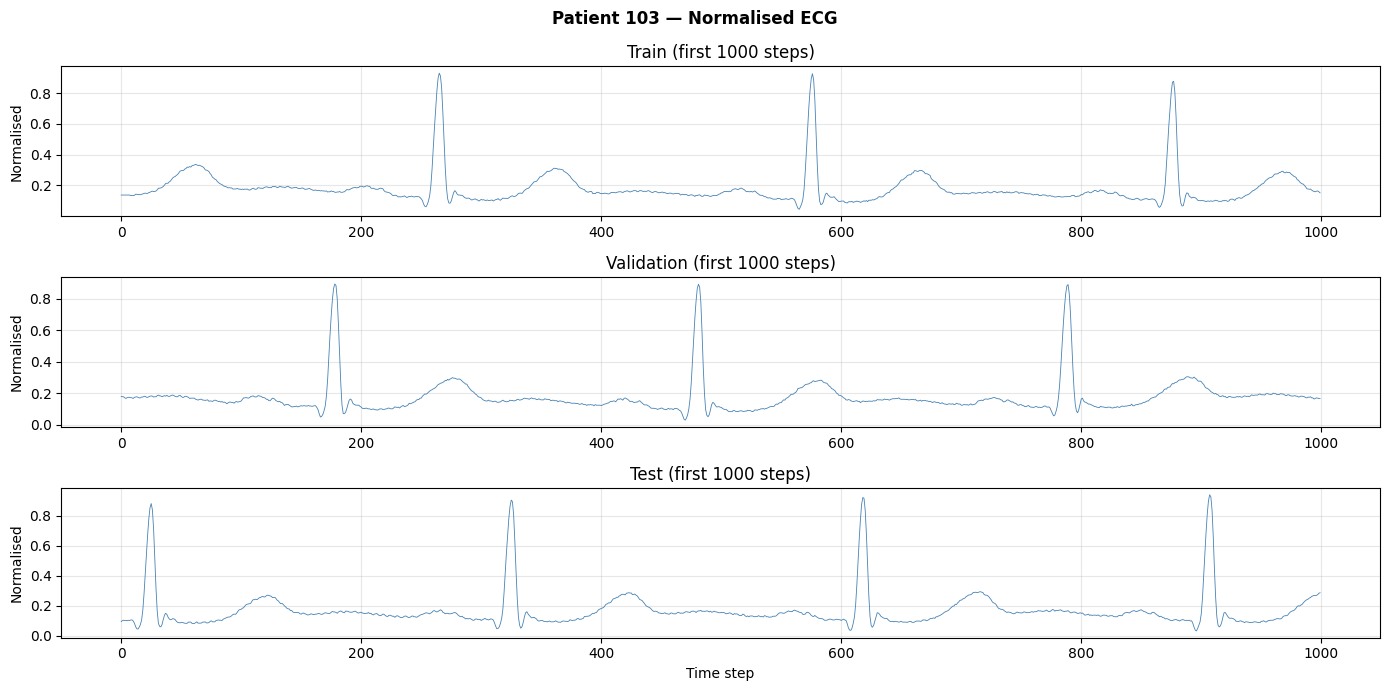

In [6]:
DEMO = '103'
d = patient_signals[DEMO]

fig, axes = plt.subplots(3, 1, figsize=(14, 7))
for ax, (title, seg) in zip(axes, [
    ('Train (first 1000 steps)', d['train'][:1000]),
    ('Validation (first 1000 steps)', d['val'][:1000]),
    ('Test (first 1000 steps)', d['test'][:1000]),
]):
    ax.plot(seg, linewidth=0.6, color='steelblue')
    ax.set_title(title)
    ax.set_ylabel('Normalised')
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Time step')
fig.suptitle(f'Patient {DEMO} - Normalised ECG', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. LSTM Model Definition

Architecture:
- **Input:** (10, 1) lookback window
- **LSTM:** 64 units (tanh activation)
- **Dense:** 32 units (ReLU)
- **Output:** H units (linear) - direct multi-step output

Training: Adam optimizer, MSE loss, Early Stopping (patience=5)

In [7]:
def build_lstm(lookback, horizon):
    '''Build a simple LSTM for direct multi-step forecasting.'''
    model = Sequential([
        Input(shape=(lookback, 1)),
        LSTM(64, activation='tanh'),
        Dense(32, activation='relu'),
        Dense(horizon)
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

# Quick test
m = build_lstm(LOOKBACK, 10)
m.summary()
del m



Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 64)                16896     
                                                                 
 dense (Dense)               (None, 32)                2080      
                                                                 
 dense_1 (Dense)             (None, 10)                330       
                                                                 
Total params: 19306 (75.41 KB)
Trainable params: 19306 (75.41 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


## 7. Train LSTM for All Horizons (10, 20, 50)

For each horizon, a separate LSTM is trained **per patient**.  
Early stopping (patience=5) monitors validation loss.  
Final metrics are **averaged across all 21 patients**.

In [8]:
results = {}
all_predictions = {}

for H in HORIZONS:
    print(f'\n{"=" * 60}')
    print(f'  HORIZON = {H} steps  ({H / FS * 1000:.1f} ms)')
    print(f'{"=" * 60}')

    patient_metrics = []
    patient_preds = {}
    total_start = time.time()

    for rid in tqdm(PATIENTS, desc=f'H={H}'):
        d = patient_signals[rid]

        # Build multi-step sequences
        X_tr, y_tr = make_sequences(d['train'], LOOKBACK, H)
        X_vl, y_vl = make_sequences(d['val'],   LOOKBACK, H)
        X_te, y_te = make_sequences(d['test'],  LOOKBACK, H)

        # Reshape for LSTM input: (samples, timesteps, 1)
        X_tr = X_tr.reshape(-1, LOOKBACK, 1)
        X_vl = X_vl.reshape(-1, LOOKBACK, 1)
        X_te = X_te.reshape(-1, LOOKBACK, 1)

        # Build and train
        model = build_lstm(LOOKBACK, H)
        model.fit(
            X_tr, y_tr,
            validation_data=(X_vl, y_vl),
            epochs=30,
            batch_size=256,
            callbacks=[EarlyStopping(monitor='val_loss', patience=5,
                                     restore_best_weights=True, verbose=0)],
            verbose=0
        )

        # Predict on test set
        y_pred = model.predict(X_te, verbose=0)

        # Compute metrics (flattened for overall score)
        rmse_val = np.sqrt(mean_squared_error(y_te, y_pred))
        mae_val  = mean_absolute_error(y_te, y_pred)
        r2_val   = r2_score(y_te.flatten(), y_pred.flatten())

        patient_metrics.append({'patient': rid,
                                'RMSE': rmse_val, 'MAE': mae_val, 'R2': r2_val})
        patient_preds[rid] = {'y_true': y_te, 'y_pred': y_pred}

        tqdm.write(f'  {rid}: RMSE={rmse_val:.4f}  MAE={mae_val:.4f}  R2={r2_val:.4f}')

        del model
        tf.keras.backend.clear_session()

    total_time = time.time() - total_start

    avg_rmse = np.mean([m['RMSE'] for m in patient_metrics])
    avg_mae  = np.mean([m['MAE']  for m in patient_metrics])
    avg_r2   = np.mean([m['R2']   for m in patient_metrics])

    results[H] = {'RMSE': round(avg_rmse, 4),
                   'MAE':  round(avg_mae, 4),
                   'R2':   round(avg_r2, 4),
                   'Time_s': round(total_time, 1),
                   'per_patient': patient_metrics}
    all_predictions[H] = patient_preds

    print(f'\n  AVG >> RMSE={avg_rmse:.4f}  MAE={avg_mae:.4f}  R2={avg_r2:.4f}  Time={total_time:.1f}s')

print('\n\nAll horizons complete!')


  HORIZON = 10 steps  (27.8 ms)


H=10:   0%|          | 0/21 [00:00<?, ?it/s]

H=10:   5%|▍         | 1/21 [00:35<11:43, 35.19s/it]

  100: RMSE=0.0352  MAE=0.0169  R2=0.8662


H=10:  10%|▉         | 2/21 [00:55<08:17, 26.16s/it]

...

  122: RMSE=0.0979  MAE=0.0591  R2=0.1917


H=50:  95%|█████████▌| 20/21 [12:01<00:42, 42.78s/it]

  123: RMSE=0.0562  MAE=0.0268  R2=0.1698


H=50: 100%|██████████| 21/21 [12:47<00:00, 36.55s/it]

  124: RMSE=0.0965  MAE=0.0514  R2=0.6031

  AVG >> RMSE=0.0842  MAE=0.0478  R2=0.3596  Time=767.5s


All horizons complete!


## 8. Results - Metrics Table

In [9]:
rows = []
for H in HORIZONS:
    r = results[H]
    rows.append({'Horizon': H, 'RMSE': r['RMSE'], 'MAE': r['MAE'],
                 'R Squared': r['R2'], 'Comp. Time (s)': r['Time_s']})

df_results = pd.DataFrame(rows).set_index('Horizon')

print('=' * 55)
print('   LSTM Multi-Step Forecasting Results')
print('   (Averaged over 21 patients)')
print('=' * 55)
display(df_results)

df_results.to_csv('lstm_results.csv')
print('\nSaved to lstm_results.csv')

   LSTM Multi-Step Forecasting Results
   (Averaged over 21 patients)


,RMSE,MAE,R Squared,Comp. Time (s)
Horizon,,,,
10,0.0418,0.0205,0.8241,687.7
20,0.0637,0.0310,0.6160,747.4
50,0.0842,0.0478,0.3596,767.5



Saved to lstm_results.csv


## 9. Actual vs Predicted Visualisation

Reconstructed signal using non-overlapping H-step prediction windows for Patient 103.

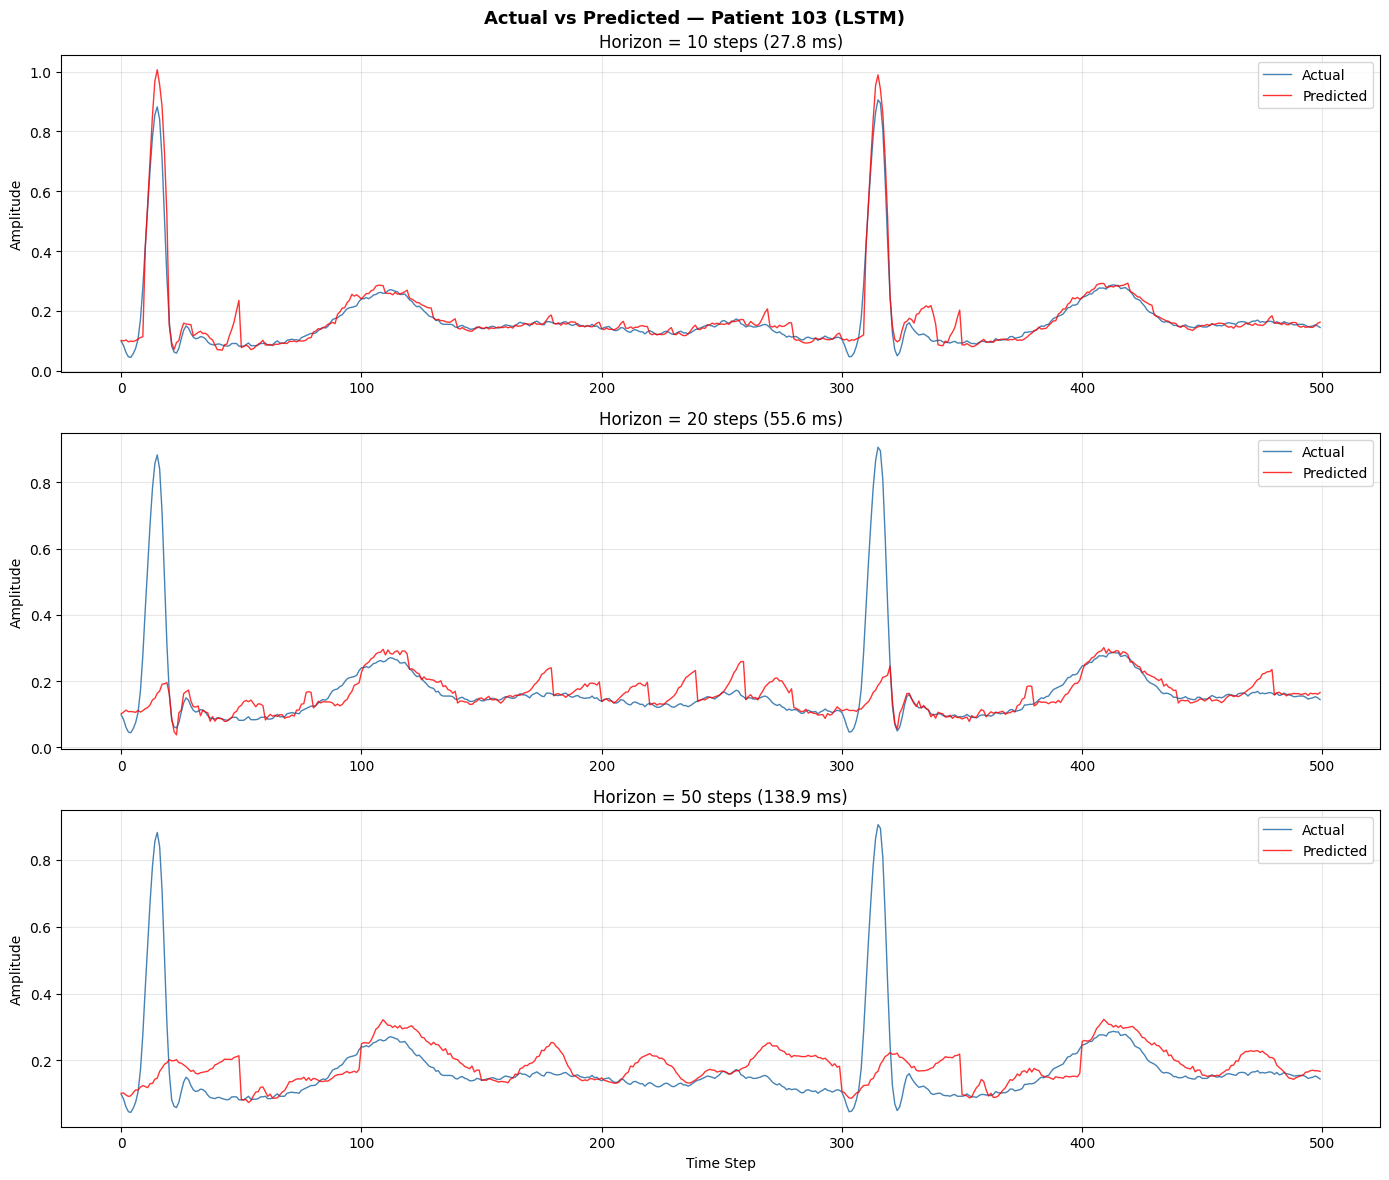

Saved: actual_vs_predicted.png


In [10]:
DEMO = '103'
N_SHOW = 500  # time steps to display

fig, axes = plt.subplots(len(HORIZONS), 1, figsize=(14, 4 * len(HORIZONS)))

for idx, H in enumerate(HORIZONS):
    ax = axes[idx]
    preds = all_predictions[H][DEMO]
    y_true = preds['y_true']
    y_pred = preds['y_pred']

    # Non-overlapping windows for clean reconstruction
    indices = list(range(0, len(y_true), H))
    n_windows = min(len(indices), N_SHOW // H + 1)
    actual    = y_true[indices[:n_windows]].flatten()[:N_SHOW]
    predicted = y_pred[indices[:n_windows]].flatten()[:N_SHOW]

    ax.plot(actual, label='Actual', color='steelblue', linewidth=1.0)
    ax.plot(predicted, label='Predicted', color='red', linewidth=1.0, alpha=0.8)
    ax.set_title(f'Horizon = {H} steps ({H / FS * 1000:.1f} ms)')
    ax.set_ylabel('Amplitude')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Time Step')
fig.suptitle(f'Actual vs Predicted - Patient {DEMO} (LSTM)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: actual_vs_predicted.png')

## 10. Step-wise RMSE Across Prediction Horizon

Shows how prediction error grows at each step within the horizon,
averaged over all test samples and all 21 patients.

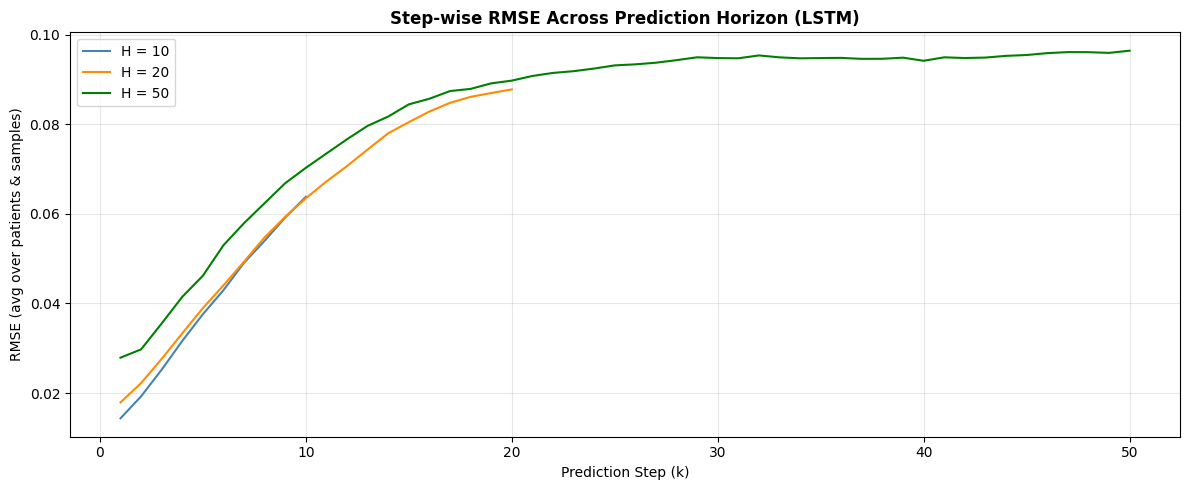

Saved: stepwise_rmse.png


In [11]:
fig, ax = plt.subplots(figsize=(12, 5))
colors = ['steelblue', 'darkorange', 'green']

for idx, H in enumerate(HORIZONS):
    stepwise_rmse = []
    for k in range(H):
        sq_errors = []
        for rid in PATIENTS:
            yt = all_predictions[H][rid]['y_true'][:, k]
            yp = all_predictions[H][rid]['y_pred'][:, k]
            sq_errors.extend((yt - yp) ** 2)
        stepwise_rmse.append(np.sqrt(np.mean(sq_errors)))

    ax.plot(range(1, H + 1), stepwise_rmse,
            label=f'H = {H}', color=colors[idx], linewidth=1.5)

ax.set_xlabel('Prediction Step (k)')
ax.set_ylabel('RMSE (avg over patients & samples)')
ax.set_title('Step-wise RMSE Across Prediction Horizon (LSTM)', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('stepwise_rmse.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: stepwise_rmse.png')

## 11. Per-Patient Breakdown

In [12]:
for H in HORIZONS:
    print(f'\nHorizon = {H}')
    print('-' * 40)
    df_p = pd.DataFrame(results[H]['per_patient']).set_index('patient')
    df_p.columns = ['RMSE', 'MAE', 'R Squared']
    display(df_p.round(4))


Horizon = 10
----------------------------------------


,RMSE,MAE,R Squared
patient,,,
100,0.0352,0.0169,0.8662
101,0.0581,0.0234,0.7201
102,0.0369,0.0162,0.7024
103,0.0268,0.0130,0.9467
104,0.0626,0.0359,0.6393
105,0.0443,0.0204,0.8523
106,0.0465,0.0183,0.7515
107,0.0409,0.0218,0.9035
108,0.0536,0.0282,0.6505



Horizon = 20
----------------------------------------


,RMSE,MAE,R Squared
patient,,,
100,0.0615,0.0262,0.5904
101,0.0692,0.0310,0.6039
102,0.0483,0.0251,0.4902
103,0.0690,0.0273,0.6456
104,0.0790,0.0480,0.4249
105,0.0736,0.0336,0.5921
106,0.0663,0.0327,0.4956
107,0.0568,0.0316,0.8138
108,0.0719,0.0404,0.3708



Horizon = 50
----------------------------------------


,RMSE,MAE,R Squared
patient,,,
100,0.0771,0.0376,0.3568
101,0.0799,0.0393,0.4710
102,0.0579,0.0346,0.2658
103,0.0956,0.0452,0.3200
104,0.0978,0.0639,0.1176
105,0.0871,0.0487,0.4291
106,0.0803,0.0481,0.2591
107,0.0855,0.0518,0.5782
108,0.0800,0.0498,0.2210


## 12. Summary & Insights

**Key observations:**

1. **Horizon 10** - Shortest prediction window (~27.8 ms). The LSTM captures ECG morphology well with relatively low error. The model handles the periodic structure of P-QRS-T complexes adequately.

2. **Horizon 20** - Error increases as the model predicts further ahead (~55.6 ms). Some amplitude flattening may appear, particularly around sharp QRS peaks where the model tends to smooth out rapid transitions.

3. **Horizon 50** - Largest horizon (~138.9 ms). Error accumulates significantly. The model struggles most with sharp QRS complexes and shows lag/smoothing artefacts. This is expected since predicting ~139 ms ahead from only ~28 ms of history is inherently challenging.

**Step-wise RMSE** confirms that prediction error grows monotonically with each additional step within the horizon. The rate of error growth accelerates for larger horizons.
